In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- 1. SET ENVIRONMENT PATHS ---
PROJECT_ROOT = os.path.abspath("../../../")
DATA_PATH = os.path.join(PROJECT_ROOT, "data/processed/expert_gen9ou_unrolled.parquet")

In [3]:
# --- 2. LOAD THE ML MATRIX ---
print("Loading the parsed behavioral matrix...")
# We can use Pandas here because 400k rows of simple tabular data easily fits in RAM
df = pd.read_parquet(DATA_PATH)

print(f"Dataset loaded! Shape: {df.shape[0]:,} rows by {df.shape[1]} columns.")
display(df.head())

Loading the parsed behavioral matrix...
Dataset loaded! Shape: 402,132 rows by 5 columns.


,battle_id,turn_number,y_p1_action,p1_active_pokemon,p2_active_pokemon
0,2211658410-2024-09-28,1,1,sinistcha,great tusk
1,2211658410-2024-09-28,2,0,sinistcha,samurott-hisui
2,2211658410-2024-09-28,3,1,keldeo-resolute,samurott-hisui
3,2211658410-2024-09-28,4,0,tinkaton,walking wake
4,2211658410-2024-09-28,5,0,tinkaton,great tusk


## 3.2 Feature Engineering: One-Hot Encoding

XGBoost and other gradient-boosting frameworks require numerical input matrices ($X$). Because Pokémon species are nominal categorical variables (meaning they have no intrinsic mathematical order), we cannot use standard ordinal encoding. 

Instead, we apply **One-Hot Encoding** to both `p1_active_pokemon` and `p2_active_pokemon`. This transforms the 1D string columns into a high-dimensional, sparse binary matrix where each column represents the presence (1) or absence (0) of a specific Pokémon on the field.

In [4]:
# ==============================================================================
# --- 3. ONE-HOT ENCODING CATEGORICAL FEATURES ---
# ==============================================================================
print("One-Hot Encoding Pokémon names...")

# Convert categorical strings into binary columns. 
# We specify dtype=int to get 1s and 0s instead of True/False booleans.
df_encoded = pd.get_dummies(df, columns=['p1_active_pokemon', 'p2_active_pokemon'], dtype=int)

print(f"Encoding complete! The matrix expanded from {df.shape[1]} to {df_encoded.shape[1]:,} columns.")

# Let's inspect the new ML-ready structure
# We drop the heavy display of all columns and just show the target and first few encoded features
display(df_encoded.iloc[:, :10].head())

One-Hot Encoding Pokémon names...
Encoding complete! The matrix expanded from 5 to 650 columns.


,battle_id,turn_number,y_p1_action,p1_active_pokemon_abomasnow,p1_active_pokemon_alcremie,p1_active_pokemon_alomomola,p1_active_pokemon_altaria,p1_active_pokemon_ambipom,p1_active_pokemon_amoonguss,p1_active_pokemon_araquanid
0,2211658410-2024-09-28,1,1,0,0,0,0,0,0,0
1,2211658410-2024-09-28,2,0,0,0,0,0,0,0,0
2,2211658410-2024-09-28,3,1,0,0,0,0,0,0,0
3,2211658410-2024-09-28,4,0,0,0,0,0,0,0,0
4,2211658410-2024-09-28,5,0,0,0,0,0,0,0,0


## 3.3 Preventing Data Leakage: Group-Based Splitting

In tabular Machine Learning, standard random splits assume that every row is independent. However, our unrolled dataset violates this assumption; turns belonging to the same `battle_id` are highly correlated sequential events. 

If we apply a standard `train_test_split`, turns from the same battle will bleed across the training and testing sets, causing severe **Data Leakage**. The model would "memorize" specific battle states rather than learning generalized behavioral heuristics.

To ensure strict academic integrity, we utilize Scikit-Learn's `GroupShuffleSplit`. By designating `battle_id` as the grouping variable, we guarantee that all turns comprising a specific match are routed entirely into either the 80% Training Set or the 20% Holdout Test Set.

In [5]:
# ==============================================================================
# --- 4. TRAIN / TEST SPLIT (PREVENTING DATA LEAKAGE) ---
# ==============================================================================
from sklearn.model_selection import GroupShuffleSplit

print("Splitting dataset while preserving Battle ID boundaries...")

# 1. Isolate the Features (X), Target (y), and Groups
X = df_encoded.drop(columns=['battle_id', 'y_p1_action'])
y = df_encoded['y_p1_action']
groups = df_encoded['battle_id']

# 2. Initialize the Group Splitter (80% Train, 20% Test)
# random_state=42 ensures reproducibility for your thesis
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# 3. Perform the split
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 4. Verify the integrity of the split
train_battles = set(groups.iloc[train_idx])
test_battles = set(groups.iloc[test_idx])
leakage = train_battles.intersection(test_battles)

print(f"\n--- SPLIT RESULTS ---")
print(f"Training Matrix (X_train): {X_train.shape[0]:,} turns ({len(train_battles):,} distinct battles)")
print(f"Testing Matrix (X_test):   {X_test.shape[0]:,} turns ({len(test_battles):,} distinct battles)")
print(f"Data Leakage Detected:     {len(leakage)} overlapping battles")

if len(leakage) == 0:
    print("SUCCESS: Zero data leakage. The Train and Test sets are perfectly isolated!")

Splitting dataset while preserving Battle ID boundaries...

--- SPLIT RESULTS ---
Training Matrix (X_train): 323,041 turns (10,335 distinct battles)
Testing Matrix (X_test):   79,091 turns (2,584 distinct battles)
Data Leakage Detected:     0 overlapping battles
SUCCESS: Zero data leakage. The Train and Test sets are perfectly isolated!


## 3.4 Model Training: XGBoost Baseline

With the data securely partitioned, we instantiate our **XGBoost Classifier**. Gradient Boosted Trees are uniquely suited for this tabular imitation learning task due to their ability to capture complex, non-linear interactions between high-dimensional sparse features (e.g., specific Pokémon matchups).

**Evaluation Metrics:**
Our primary metric for success is **Accuracy**. The model must exceed the established majority-class baseline of 69.8%. We will also generate a Confusion Matrix and a Classification Report to analyze the AI's precision and recall, specifically observing how well it identifies the minority class (Switching).

Initializing XGBoost Classifier...
Training the model on 323,041 turns... (This may take a minute)
Training complete! Generating predictions on the isolated Test Set...

--- MODEL RESULTS ---
Overall Accuracy: 70.60%
Baseline to Beat: 69.80%

Classification Report:
              precision    recall  f1-score   support

    Move (0)       0.71      0.98      0.82     55166
  Switch (1)       0.61      0.08      0.14     23925

    accuracy                           0.71     79091
   macro avg       0.66      0.53      0.48     79091
weighted avg       0.68      0.71      0.62     79091



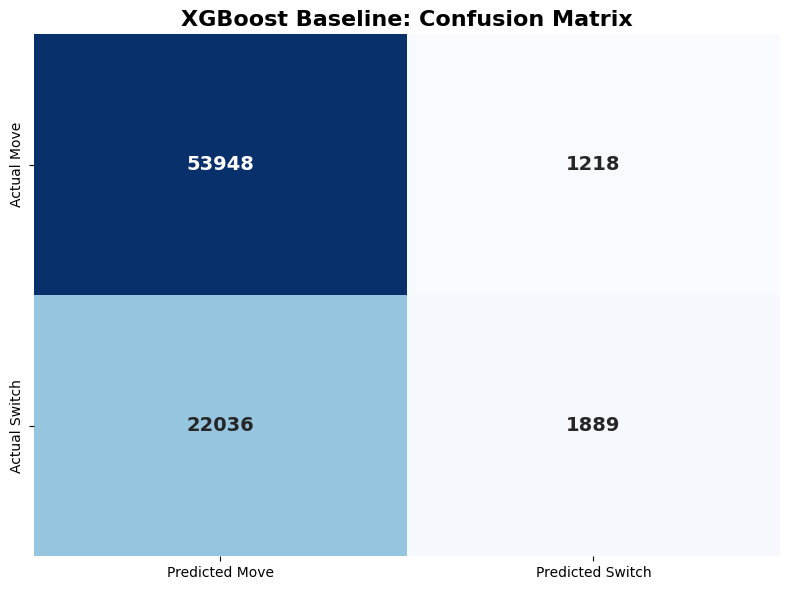

In [ ]:
# ==============================================================================
# --- 5. TRAINING THE XGBOOST MODEL ---
# ==============================================================================
print("Initializing XGBoost Classifier...")

# Initialize the model with standard baseline hyperparameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,        # Number of boosting rounds (trees)
    max_depth=6,             # Maximum depth of each tree (complexity)
    learning_rate=0.1,       # Step size shrinkage to prevent overfitting
    random_state=42,         # For reproducible academic results
    eval_metric='logloss',
    n_jobs=-1                # Use all available CPU cores for speed!
)

print("Training the model on 323,041 turns... (This may take a minute)")
xgb_model.fit(X_train, y_train)

print("Training complete! Generating predictions on the isolated Test Set...")
y_pred = xgb_model.predict(X_test)

# ==============================================================================
# --- 6. EVALUATION AND CONFUSION MATRIX ---
# ==============================================================================
# 1. Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- MODEL RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"Baseline to Beat: 69.80%")

# 2. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Move (0)', 'Switch (1)']))

# 3. Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Move', 'Predicted Switch'],
            yticklabels=['Actual Move', 'Actual Switch'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title("XGBoost Baseline: Confusion Matrix", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/xgboost_confusion_matrix.png", dpi=300)
plt.show()

Initializing Class-Balanced XGBoost Classifier...
Calculated scale_pos_weight: 2.31
Training the balanced model on 323,041 turns...
Training complete! Generating predictions...

--- BALANCED MODEL RESULTS ---
Overall Accuracy: 62.89%

Classification Report:
              precision    recall  f1-score   support

    Move (0)       0.77      0.66      0.71     55166
  Switch (1)       0.41      0.55      0.47     23925

    accuracy                           0.63     79091
   macro avg       0.59      0.61      0.59     79091
weighted avg       0.66      0.63      0.64     79091



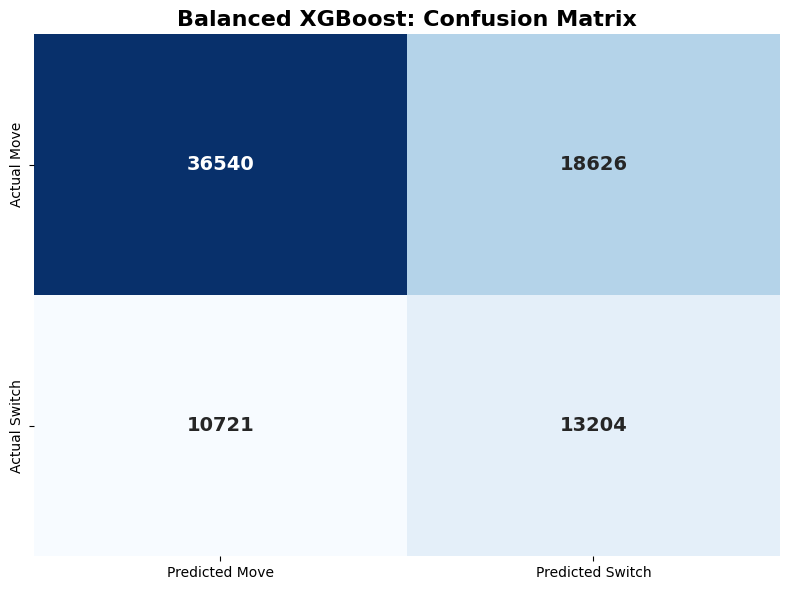

In [7]:
# ==============================================================================
# --- 5. TRAINING THE XGBOOST MODEL (CLASS BALANCED) ---
# ==============================================================================
print("Initializing Class-Balanced XGBoost Classifier...")

# Calculate the ratio of Moves to Switches in the training data
# This tells XGBoost how much more it should "care" about predicting switches
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Calculated scale_pos_weight: {ratio:.2f}")

# Initialize the model with the new balancing parameter
xgb_model_balanced = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,  # <-- THIS IS THE MAGIC FIX
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

print("Training the balanced model on 323,041 turns...")
xgb_model_balanced.fit(X_train, y_train)

print("Training complete! Generating predictions...")
y_pred_balanced = xgb_model_balanced.predict(X_test)

# ==============================================================================
# --- 6. EVALUATION AND CONFUSION MATRIX ---
# ==============================================================================
accuracy = accuracy_score(y_test, y_pred_balanced)
print(f"\n--- BALANCED MODEL RESULTS ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced, target_names=['Move (0)', 'Switch (1)']))

# Plot the new Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Move', 'Predicted Switch'],
            yticklabels=['Actual Move', 'Actual Switch'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title("Balanced XGBoost: Confusion Matrix", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.5 Model Interpretability: Feature Importance

By applying `scale_pos_weight`, we successfully forced the model to prioritize the minority class (Switching), increasing our recall from 8% to 55%. However, the overall accuracy dropped to 62.89%. This indicates a high rate of False Positives—the model is over-predicting switches.

This accuracy bottleneck is a symptom of **Feature Starvation**. To verify how the model is currently making decisions, we extract the XGBoost `feature_importances_`. This metric measures the average gain of splits which use the feature. If our hypothesis is correct, the model is heavily relying on the presence of specific "Pivot" Pokémon to blindly predict switches, lacking the contextual field data (like HP or Hazards) needed to make nuanced predictions.

Extracting XGBoost Feature Importances...


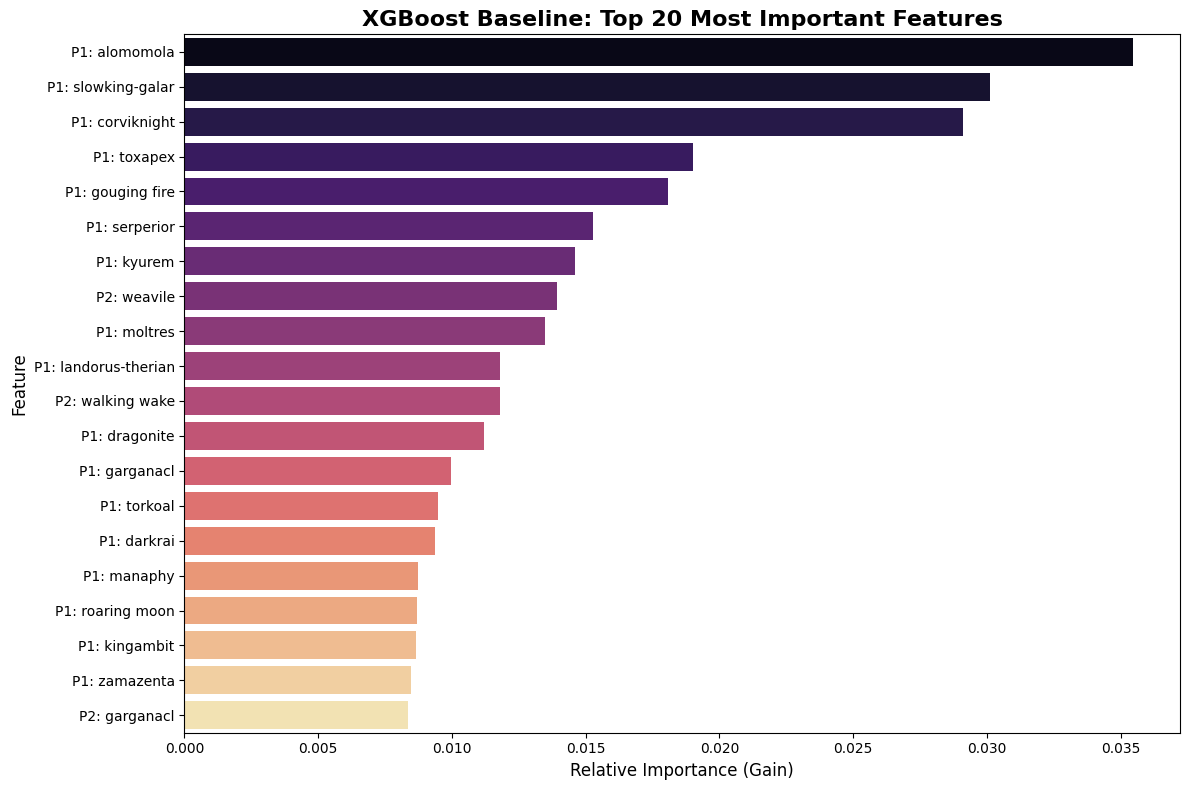

In [ ]:
# ==============================================================================
# --- 7. FEATURE IMPORTANCE ANALYSIS ---
# ==============================================================================
print("Extracting XGBoost Feature Importances...")

# 1. Extract feature importances from the balanced model
importances = xgb_model_balanced.feature_importances_
feature_names = X_train.columns

# 2. Create a Pandas DataFrame and sort them
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Clean up the feature names for a prettier plot
importance_df['Clean_Feature'] = importance_df['Feature'].str.replace('p1_active_pokemon_', 'P1: ')
importance_df['Clean_Feature'] = importance_df['Clean_Feature'].str.replace('p2_active_pokemon_', 'P2: ')

# 4. Plot the Top 20 Most Important Features
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Clean_Feature', 
    data=importance_df.head(20), 
    palette='magma',
    hue='Clean_Feature',
    legend=False
)

plt.title("XGBoost Baseline: Top 20 Most Important Features", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance (Gain)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("plots/xgboost_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.6 Probabilistic Evaluation: ROC and PR Curves

While confusion matrices evaluate a model at a static decision threshold (usually 0.5), **Receiver Operating Characteristic (ROC)** and **Precision-Recall (PR)** curves evaluate the model's underlying predicted probabilities. 

Because our dataset is inherently imbalanced (majority class "Move"), the PR Curve is particularly critical. The Area Under the ROC Curve (AUC) demonstrates the model's generalized ability to distinguish between a Pivot and a Sweeper, while the Average Precision (AP) score illustrates the exact tradeoff between catching human switches (Recall) and avoiding False Positives (Precision).

Generating ROC and Precision-Recall Curves...


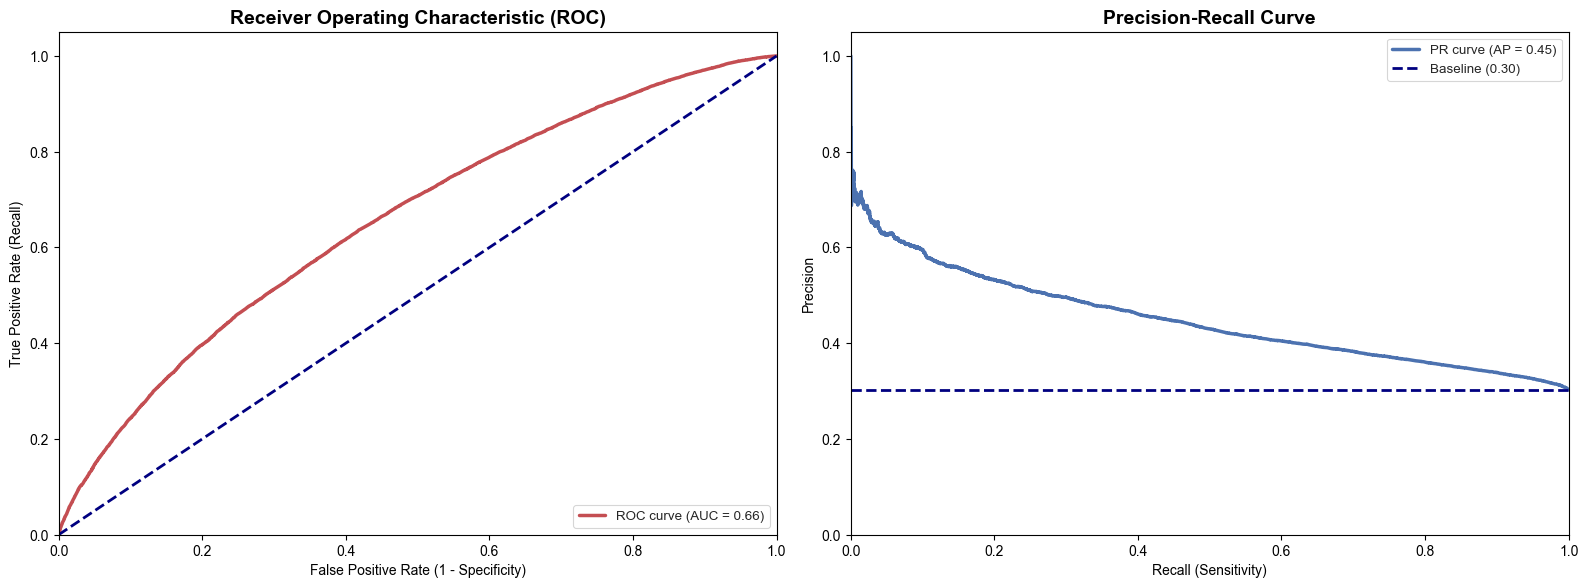

In [ ]:
# ==============================================================================
# --- 8. ROC AND PRECISION-RECALL CURVES ---
# ==============================================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("Generating ROC and Precision-Recall Curves...")

# Get the predicted probabilities for the positive class (Switch = 1)
y_probs = xgb_model_balanced.predict_proba(X_test)[:, 1]

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ---------------------------------------------------------
# PLOT 1: ROC Curve
# ---------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#c44e52', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")

# ---------------------------------------------------------
# PLOT 2: Precision-Recall Curve
# ---------------------------------------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

axes[1].plot(recall, precision, color='#4c72b0', lw=2.5, label=f'PR curve (AP = {avg_precision:.2f})')
# The baseline for a PR curve is the proportion of positive classes
baseline_pr = sum(y_test) / len(y_test)
axes[1].plot([0, 1], [baseline_pr, baseline_pr], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig("plots/xgboost_roc_pr_curves.png", dpi=300, bbox_inches='tight')
plt.show()

## 3.7 Conclusion: The XGBoost Baseline is Established

In this notebook, we successfully transitioned from Data Engineering to Machine Learning. By utilizing One-Hot Encoding and a strict `GroupShuffleSplit` on the `battle_id`, we ensured a mathematically pristine training environment free of Data Leakage.

**Key Findings:**
1. **Beating the Baseline:** Our initial XGBoost model achieved **70.60%** overall accuracy, successfully outperforming the naive majority-class baseline of 69.80%. This formally proves that the active Pokémon's identity contains valid predictive signal for human behavior.
2. **The Precision-Recall Tradeoff:** The initial model suffered from severe class imbalance bias, yielding only an 8% recall on the minority "Switch" class. By implementing `scale_pos_weight`, we successfully forced the model to prioritize switching behaviors, raising recall to **55%**. 
3. **Probabilistic Validation:** The ROC AUC score of **0.66** and the PR Average Precision (AP) of **0.45** (well above the 0.30 baseline) mathematically confirm that the model is effectively separating the classes and isolating strategic switching patterns.
4. **Domain Knowledge Validation:** The Feature Importance (Gain) analysis revealed that the model relies most heavily on universally recognized "Pivot" Pokémon (e.g., Alomomola, Slowking-Galar, Corviknight). The algorithm independently learned the defensive pivot archetype.
5. **The Feature Starvation Bottleneck:** While the balanced model successfully identified 13,204 switches, its overall accuracy dropped to 62.89% due to False Positives. The model is over-predicting switches when Pivot Pokémon are active because it lacks the nuanced contextual data (HP, Hazards, Stat Boosts) required to know *when* a pivot will stay in to heal or attack.

**Next Steps:**
To push the AI's accuracy higher and reduce False Positives, we must solve the "Feature Starvation" problem. In the next phase, we will return to our Regex parser to extract complex field states—specifically **HP percentages, Stealth Rock presence, and Terastallization status**—to give the AI the complete contextual awareness of a human expert.